In [1]:
import os
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CSV_PATH = "ind_poverty.csv"
TRAIN_PATH = "train_poverty.csv"
TEST_PATH = "test_poverty.csv"

# --- Preprocess the poverty dataset ---
def preprocess(df):
    df = df.copy()
    df["text_for_nlp"] = (
        df["State"].astype(str) + ". "
        + "Rural poverty expenditure per capita: " + df["Rural 2011-12 Poverty Expenditure Per Capita"].astype(str) + ". "
        + "Urban poverty expenditure per capita: " + df["Urban 2011-12 Poverty Expenditure Per Capita"].astype(str) + ". "
        + "Headcount ratio: " + df["Headcount Ratio (%)"].astype(str) + "%. "
        + "2011 rural percentage: " + df["2011 rural percentage"].astype(str) + ". "
        + "FII rank: " + df["FII Rank"].astype(str) + ". "
        + "CFII: " + df["CFII"].astype(str) + ". "
        + "CDI: " + df["CDI"].astype(str)
    ).str.lower()
    return df

# Load data
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
else:
    raise FileNotFoundError("ind_poverty.csv not found. Please ensure it exists in the same directory.")

# Preprocess and split
df = preprocess(df)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED, shuffle=True)

train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH, index=False)

print(f"✅ Data prepared: {len(train_df)} train, {len(test_df)} test.")




✅ Data prepared: 28 train, 8 test.


In [2]:
# model

In [2]:
import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

MODEL_PATH = "poverty_vectorizer.pkl"
MATRIX_PATH = "poverty_tfidf_matrix.pkl"

# Load train and full dataset
train_df = pd.read_csv("train_poverty.csv")
full_df = pd.read_csv("ind_poverty.csv")

# Preprocess
def preprocess(df):
    df = df.copy()
    df["text_for_nlp"] = (
        df["State"].astype(str) + ". "
        + "Rural poverty expenditure per capita: " + df["Rural 2011-12 Poverty Expenditure Per Capita"].astype(str) + ". "
        + "Urban poverty expenditure per capita: " + df["Urban 2011-12 Poverty Expenditure Per Capita"].astype(str) + ". "
        + "Headcount ratio: " + df["Headcount Ratio (%)"].astype(str) + "%. "
        + "2011 rural percentage: " + df["2011 rural percentage"].astype(str) + ". "
        + "FII rank: " + df["FII Rank"].astype(str) + ". "
        + "CFII: " + df["CFII"].astype(str) + ". "
        + "CDI: " + df["CDI"].astype(str)
    ).str.lower()
    return df

train_df = preprocess(train_df)
full_df = preprocess(full_df)

# Train TF-IDF model
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_df["text_for_nlp"])

# Transform full data
tfidf_matrix = vectorizer.transform(full_df["text_for_nlp"])

# Save model and matrix
joblib.dump(vectorizer, MODEL_PATH)
joblib.dump({"matrix": tfidf_matrix, "df": full_df}, MATRIX_PATH)

print(f"✅ Model trained and saved to {MODEL_PATH} and {MATRIX_PATH}")



✅ Model trained and saved to poverty_vectorizer.pkl and poverty_tfidf_matrix.pkl


TF-IDF matrix shape: (36, 518), Sparsity: 8.21%

Top 20 words/phrases by TF-IDF importance:
nan: 5.51
per: 4.53
poverty expenditure: 4.53
poverty: 4.53
per capita: 4.53
expenditure: 4.53
capita: 4.53
expenditure per: 4.53
rural: 4.53
fii rank: 2.26
cdi: 2.26
cfii: 2.26
ratio: 2.26
fii: 2.26
headcount: 2.26
headcount ratio: 2.26
rank: 2.26
2011 rural: 2.26
2011: 2.26
rural percentage: 2.26


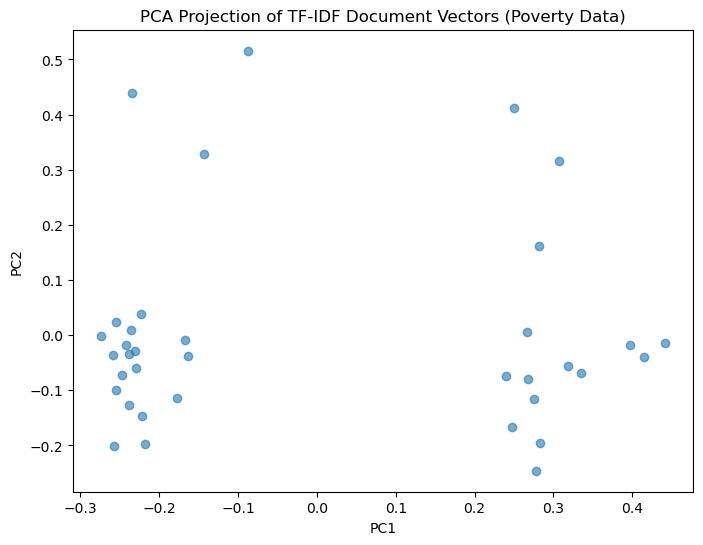

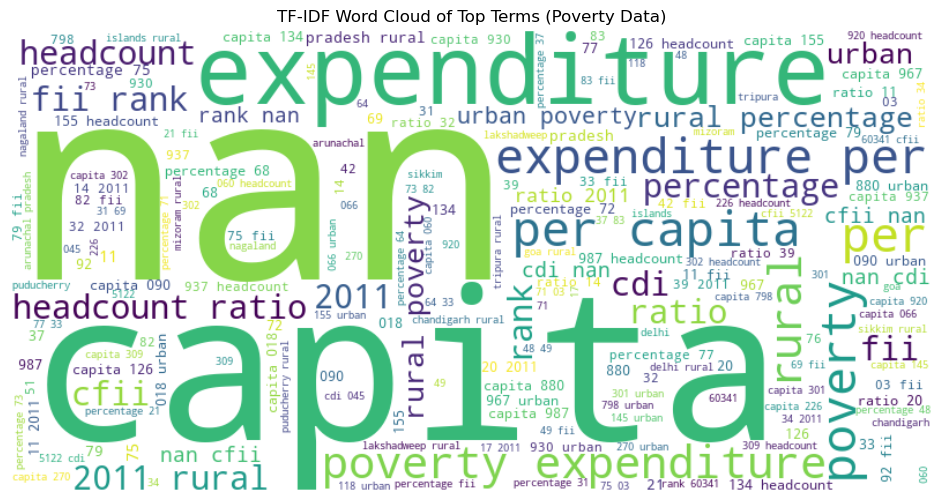

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from wordcloud import WordCloud

# 1. Sparsity
sparsity = 100.0 * (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}, Sparsity: {sparsity:.2f}%")

# 2. Top 20 words
feature_names = np.array(vectorizer.get_feature_names_out())
tfidf_sum = np.array(tfidf_matrix.sum(axis=0)).flatten()
top_indices = tfidf_sum.argsort()[::-1][:20]
print("\nTop 20 words/phrases by TF-IDF importance:")
for word, score in zip(feature_names[top_indices], tfidf_sum[top_indices]):
    print(f"{word}: {score:.2f}")

# 3. PCA projection
pca = PCA(n_components=2)
reduced = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], alpha=0.6)
plt.title("PCA Projection of TF-IDF Document Vectors (Poverty Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 4. Word Cloud
top_words_dict = {feature_names[i]: tfidf_sum[i] for i in range(len(feature_names))}
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words_dict)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("TF-IDF Word Cloud of Top Terms (Poverty Data)")
plt.show()


In [5]:
# Load model

In [9]:
import textwrap
import joblib
from sklearn.metrics.pairwise import cosine_similarity

MODEL_PATH = "poverty_vectorizer.pkl"
MATRIX_PATH = "poverty_tfidf_matrix.pkl"

vectorizer = joblib.load(MODEL_PATH)
data = joblib.load(MATRIX_PATH)

tfidf_matrix = data["matrix"]
df = data["df"]

def answer_query(query, top_k=3):
    query_vec = vectorizer.transform([query.lower()])
    sims = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_idx = sims.argsort()[::-1][:top_k]

    print(f"\n🔎 Query: {query}")
    for idx in top_idx:
        row = df.iloc[idx]
        snippet = textwrap.shorten(row["text_for_nlp"], width=250, placeholder="...")
        print(f"\n📌 {row['State']} | Score={sims[idx]:.3f}")
        print(f"Rural Poverty: {row['Rural 2011-12 Poverty Expenditure Per Capita']}")
        print(f"Urban Poverty: {row['Urban 2011-12 Poverty Expenditure Per Capita']}")
        print(f"Headcount Ratio (%): {row['Headcount Ratio (%)']}")
        print(f"Rural % (2011): {row['2011 rural percentage']}")
        print(f"FII Rank: {row['FII Rank']} | CFII: {row['CFII']} | CDI: {row['CDI']}")
        print(f"Summary: {snippet}")

# Example Query
answer_query("states with high rural poverty and low CDI", top_k=3)



🔎 Query: states with high rural poverty and low CDI

📌 Rajasthan | Score=0.320
Rural Poverty: 905
Urban Poverty: 1,002
Headcount Ratio (%): 8.3
Rural % (2011): 75.11
FII Rank: 0.17369 | CFII: 0.0767 | CDI: 0.626
Summary: rajasthan. rural poverty expenditure per capita: 905. urban poverty expenditure per capita: 1,002. headcount ratio: 8.3%. 2011 rural percentage: 75.11. fii rank: 0.17369. cfii: 0.0767. cdi: 0.626

📌 Uttarkhand | Score=0.312
Rural Poverty: 880
Urban Poverty: 1,082
Headcount Ratio (%): 29.4
Rural % (2011): 69.45
FII Rank: 0.32742 | CFII: 0.1613 | CDI: 0.383
Summary: uttarkhand. rural poverty expenditure per capita: 880. urban poverty expenditure per capita: 1,082. headcount ratio: 29.4%. 2011 rural percentage: 69.45. fii rank: 0.32742. cfii: 0.1613. cdi: 0.383

📌 Madhya Pradesh | Score=0.297
Rural Poverty: 771
Urban Poverty: 897
Headcount Ratio (%): 7.1
Rural % (2011): 72.37
FII Rank: 0.16104 | CFII: 0.0752 | CDI: 0.759
Summary: madhya pradesh. rural poverty expenditure

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import joblib

# Load saved models
vectorizer = joblib.load("poverty_vectorizer.pkl")
data = joblib.load("poverty_tfidf_matrix.pkl")
tfidf_matrix = data["matrix"]
full_df = data["df"]

# Query function
def query_poverty(question, top_k=3):
    """
    Returns top_k matching states for the input query.
    """
    query_text = question.lower()
    query_vec = vectorizer.transform([query_text])
    sims = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = sims.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        row = full_df.iloc[idx]
        results.append({
            "State": row["State"],
            "Rural Poverty (₹)": row["Rural 2011-12 Poverty Expenditure Per Capita"],
            "Urban Poverty (₹)": row["Urban 2011-12 Poverty Expenditure Per Capita"],
            "Headcount Ratio (%)": row["Headcount Ratio (%)"],
            "Rural % (2011)": row["2011 rural percentage"],
            "FII Rank": row["FII Rank"],
            "CFII": row["CFII"],
            "CDI": row["CDI"],
            "Similarity": float(sims[idx])
        })
    return results

# Demo
question = "states with low headcount ratio and high CDI"
top_matches = query_poverty(question, top_k=3)

print(f"\n🔎 Query: {question}\n")
for i, res in enumerate(top_matches, 1):
    print(f"{i}. {res['State']} | Similarity: {res['Similarity']:.2f}")
    print(f"   • Rural Poverty: {res['Rural Poverty (₹)']}")
    print(f"   • Urban Poverty: {res['Urban Poverty (₹)']}")
    print(f"   • Headcount Ratio (%): {res['Headcount Ratio (%)']}")
    print(f"   • FII Rank: {res['FII Rank']} | CFII: {res['CFII']} | CDI: {res['CDI']}\n")



🔎 Query: states with low headcount ratio and high CDI

1. Rajasthan | Similarity: 0.21
   • Rural Poverty: 905
   • Urban Poverty: 1,002
   • Headcount Ratio (%): 8.3
   • FII Rank: 0.17369 | CFII: 0.0767 | CDI: 0.626

2. Uttarkhand | Similarity: 0.21
   • Rural Poverty: 880
   • Urban Poverty: 1,082
   • Headcount Ratio (%): 29.4
   • FII Rank: 0.32742 | CFII: 0.1613 | CDI: 0.383

3. Madhya Pradesh | Similarity: 0.20
   • Rural Poverty: 771
   • Urban Poverty: 897
   • Headcount Ratio (%): 7.1
   • FII Rank: 0.16104 | CFII: 0.0752 | CDI: 0.759

